# UK Energy Drinks — Weekly Demand Prediction

Predicting `Estimated Weekly Sales GBP` from the `UK_energy_drinks_weekly_2020_2025.xlsx` workbook using five regression models:

1. Linear Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

**Read this before trusting the numbers below:** the workbook's `Overview` sheet states the 313 weekly values are *modelled allocations* of public annual/rolling market-value anchors, not observed weekly EPOS sales. `Model Weight`, `Annual Benchmark GBP`, and `Weekly Share of Annual` are the deterministic inputs used to build the target column, so they are excluded from the feature set as label leakage (see the leakage note below). The remaining signal is genuinely weaker than the raw R² you'd get by keeping those columns — that's expected and it's the more honest version of the problem.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
DATA_PATH = '../data/UK_energy_drinks_weekly_2020_2025.xlsx'
MODELS_DIR = '../models_extended'
OUTPUTS_DIR = '../outputs_extended'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

## 1. Load every sheet

In [2]:
xls = pd.ExcelFile(DATA_PATH)
print('Sheets found:', xls.sheet_names)

sheets = {name: pd.read_excel(xls, sheet_name=name) for name in xls.sheet_names}
for name, sheet_df in sheets.items():
    print(f"  - {name}: {sheet_df.shape}")

Sheets found: ['Overview', 'Weekly_Sales', 'Annual_Benchmarks', 'Codebook']
  - Overview: (24, 4)
  - Weekly_Sales: (313, 13)
  - Annual_Benchmarks: (6, 7)
  - Codebook: (19, 6)


In [3]:
# Overview sheet is a free-text methodology note, not a table
for val in sheets['Overview'].iloc[:, 0].dropna():
    print('-', val)

- IMPORTANT: Complete observed week-by-week NIQ/IRI EPOS sales are not publicly available. The 313 weekly values in this workbook are MODELLED allocations of public annual/rolling market-value anchors. Use them for exploratory analysis and dataset practice, not as measured weekly sales.
- Year
- 2020
- 2021
- 2022
- 2023
- 2024
- 2025
- Methodology
- Weekly model: each market-value anchor is distributed across that ISO year using a deterministic seasonality weight. Summer weights are higher than early-year weights, with a small repeating within-month variation. Weights are normalized within each year so the weekly estimates sum exactly to the benchmark. The seasonality profile is an assumption, not proprietary weekly sales data.
- Next extension
- Age, sex, region, ethnicity, sugar-status and brand columns are intentionally NOT fabricated here. They need compatible public survey/panel sources. The Codebook sheet contains placeholders for those dimensions.


In [4]:
# The public annual market-value anchors each year's weekly values are distributed across
sheets['Annual_Benchmarks']

,ISO Year,Benchmark GBP,Scope,Measurement / timing,Scope notes,Benchmark type,Source URL
0,2020,1400000000,Sports & Energy,"Nielsen, Dec 2020","Public market value; includes sports + energy,...",Proxy / scope mismatch,https://www.slrmag.co.uk/changing-face-of-summ...
1,2021,1400000000,Energy drinks,"Nielsen Total Coverage, MAT to 11 Sep 2021","GB energy drinks sector; rolling MAT, not cale...",Rolling MAT,https://grocerytrader.co.uk/monster-starts-the...
2,2022,1700000000,Energy drinks,IRI; published Jan 2023,Trade-publication market value around end-2022...,Market-value anchor,https://grocerytrader.co.uk/expanding-category...
3,2023,1800000000,Energy drinks,IRI; published Jul 2023,Total-market value reported during 2023; rolli...,Rolling/current value,https://www.conveniencestore.co.uk/products-in...
4,2024,2100000000,Energy drinks,"NIQ Total Coverage, MAT to 28 Dec 2024",Source states 'more than £2.1bn'; £2.1bn is us...,Lower-bound proxy,https://grocerytrader.co.uk/monster-energy-off...
5,2025,2200000000,Energy drinks,Industry statement published Jul 2025,UK category stated as worth £2.2bn and growing...,Rolling/current value,https://www.foodmanufacture.co.uk/Article/2025...


In [5]:
codebook = sheets['Codebook'].copy()
codebook.columns = codebook.iloc[2]
codebook = codebook.iloc[3:].reset_index(drop=True)
codebook

2,Field,Sheet,Type,Meaning,Observed / modelled,Notes
0,Week Start,Weekly_Sales,Date,Monday of ISO week,Calendar,ISO week convention
1,Week End,Weekly_Sales,Date,Sunday of ISO week,Calendar,NaN
2,ISO Year,Weekly_Sales,Integer,ISO week-year,Calendar,2020–2025
3,ISO Week,Weekly_Sales,Integer,ISO week number,Calendar,2020 has 53 ISO weeks
4,Model Weight,Weekly_Sales,Decimal,Seasonality input,Model input,Not an observed sales measure
5,Annual Benchmark GBP,Weekly_Sales,Currency,Public market-value anchor,Public source,Several are rolling/MAT values
6,Estimated Weekly Sales GBP,Weekly_Sales,Currency,Modelled weekly sales value,MODELLED,Normalized to annual benchmark
7,Weekly Share of Annual,Weekly_Sales,Percent,Estimated weekly fraction,MODELLED,NaN
8,Data Status,Weekly_Sales,Text,Provenance warning,Metadata,NaN
9,Source URL,Weekly_Sales,URL,Source for annual anchor,Public source,NaN


## 2. The modelling table: `Weekly_Sales`

In [6]:
df = sheets['Weekly_Sales'].copy()
df = df.sort_values('Week Start').reset_index(drop=True)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Week Start                  313 non-null    datetime64[ns]
 1   Week End                    313 non-null    datetime64[ns]
 2   ISO Year                    313 non-null    int64         
 3   ISO Week                    313 non-null    int64         
 4   Month                       313 non-null    object        
 5   Quarter                     313 non-null    object        
 6   Season                      313 non-null    object        
 7   Model Weight                313 non-null    float64       
 8   Annual Benchmark GBP        313 non-null    int64         
 9   Estimated Weekly Sales GBP  313 non-null    float64       
 10  Weekly Share of Annual      313 non-null    float64       
 11  Data Status                 313 non-null    object        

,Week Start,Week End,ISO Year,ISO Week,Month,Quarter,Season,Model Weight,Annual Benchmark GBP,Estimated Weekly Sales GBP,Weekly Share of Annual,Data Status,Source URL
0,2019-12-30,2020-01-05,2020,1,January,Q1,Winter,0.956785,1400000000,2.498403e+07,0.017846,MODELLED — not observed weekly EPOS data,https://www.slrmag.co.uk/changing-face-of-summ...
1,2020-01-06,2020-01-12,2020,2,January,Q1,Winter,0.944232,1400000000,2.465624e+07,0.017612,MODELLED — not observed weekly EPOS data,https://www.slrmag.co.uk/changing-face-of-summ...
2,2020-01-13,2020-01-19,2020,3,January,Q1,Winter,0.924282,1400000000,2.413529e+07,0.017239,MODELLED — not observed weekly EPOS data,https://www.slrmag.co.uk/changing-face-of-summ...
3,2020-01-20,2020-01-26,2020,4,January,Q1,Winter,0.931806,1400000000,2.433176e+07,0.017380,MODELLED — not observed weekly EPOS data,https://www.slrmag.co.uk/changing-face-of-summ...
4,2020-01-27,2020-02-02,2020,5,January,Q1,Winter,0.953653,1400000000,2.490224e+07,0.017787,MODELLED — not observed weekly EPOS data,https://www.slrmag.co.uk/changing-face-of-summ...


## 3. Exploratory data analysis

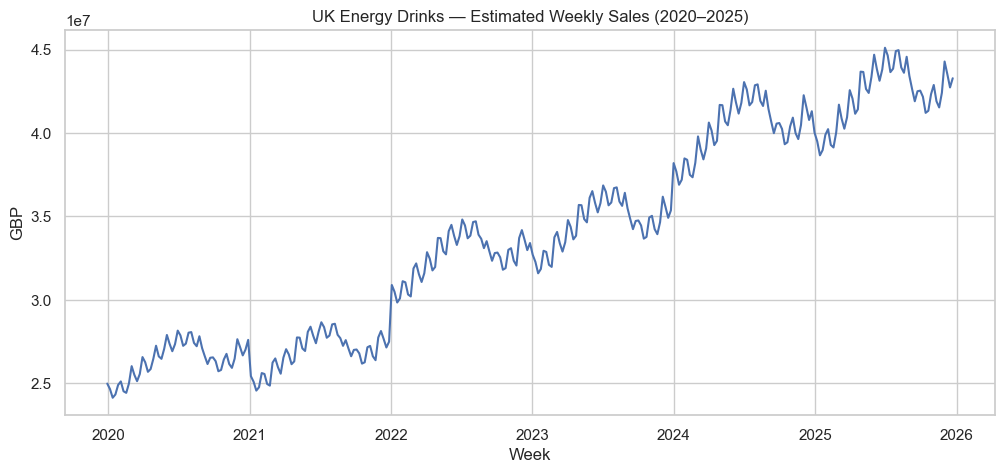

In [7]:
fig, ax = plt.subplots()
ax.plot(df['Week Start'], df['Estimated Weekly Sales GBP'], color='#4C72B0')
ax.set_title('UK Energy Drinks — Estimated Weekly Sales (2020–2025)')
ax.set_ylabel('GBP')
ax.set_xlabel('Week')
plt.show()

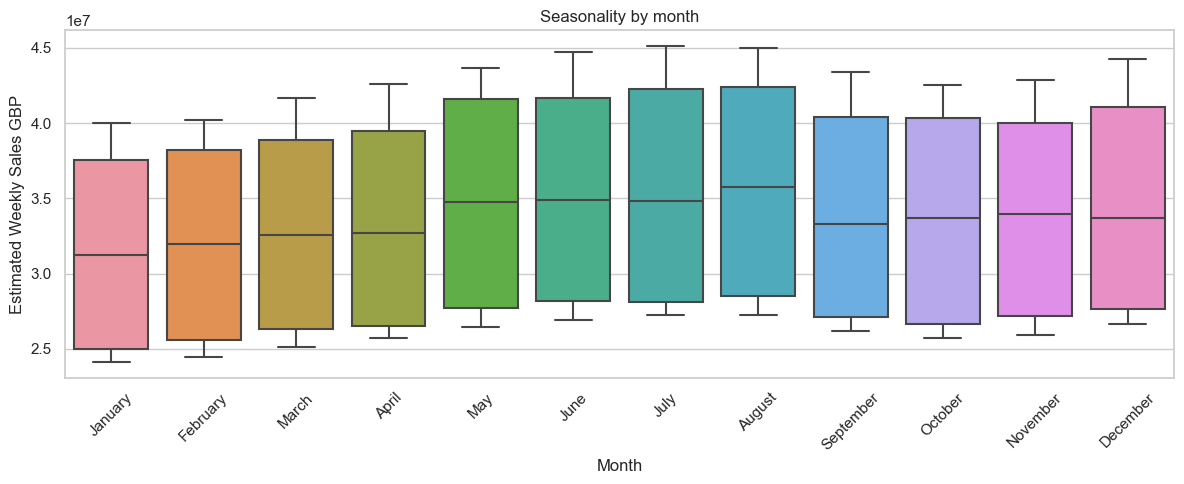

In [8]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Month', y='Estimated Weekly Sales GBP', order=month_order, ax=ax)
ax.set_title('Seasonality by month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

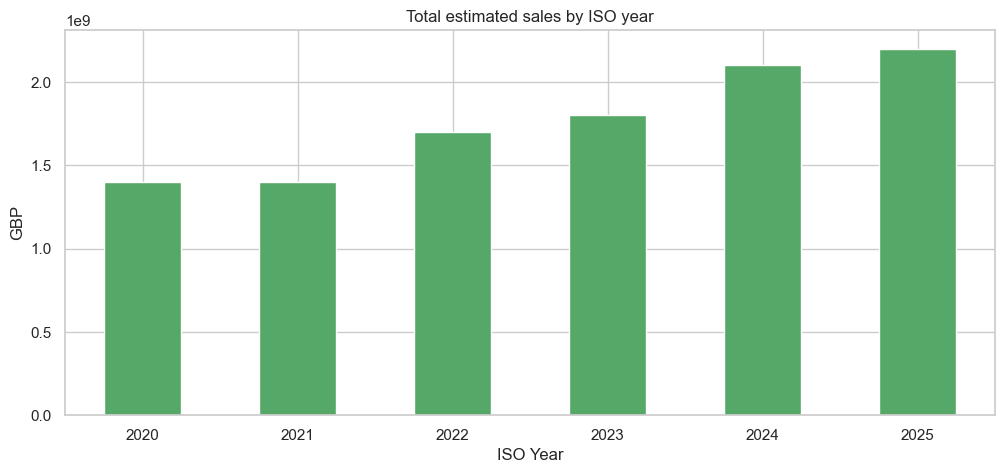

In [9]:
yearly = df.groupby('ISO Year')['Estimated Weekly Sales GBP'].sum()
ax = yearly.plot(kind='bar', color='#55A868', title='Total estimated sales by ISO year')
ax.set_ylabel('GBP')
plt.xticks(rotation=0)
plt.show()

## 4. Feature engineering — and why some columns are excluded

`Estimated Weekly Sales GBP` is built in the source workbook as `Annual Benchmark GBP × (normalized Model Weight)`, and `Weekly Share of Annual` is that same normalized weight. Feeding any of those three columns into a model would let it reconstruct the target almost exactly — that's leakage, not a genuine forecast. `Data Status` and `Source URL` are metadata, not signal. All five are dropped.

What's left to predict demand from:
- **Calendar features** — ISO year, ISO week (cyclically encoded), month, quarter, season, and a running time index for trend.
- **Autoregressive features** — lags of the target itself (1, 2, 4, 52 weeks back) and rolling means/std, all computed strictly from *past* values so no row sees its own future or present value.

In [10]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.sort_values('Week Start').reset_index(drop=True).copy()

    # Calendar signal (all knowable ahead of time)
    d['time_index'] = np.arange(len(d))
    d['week_sin'] = np.sin(2 * np.pi * d['ISO Week'] / 52)
    d['week_cos'] = np.cos(2 * np.pi * d['ISO Week'] / 52)
    d['month_num'] = d['Week Start'].dt.month
    d['quarter_num'] = d['Week Start'].dt.quarter
    d['year'] = d['ISO Year']

    # Autoregressive / momentum signal from the target's own history
    target = d['Estimated Weekly Sales GBP']
    d['lag_1'] = target.shift(1)
    d['lag_2'] = target.shift(2)
    d['lag_4'] = target.shift(4)
    d['lag_52'] = target.shift(52)
    d['roll_mean_4'] = target.shift(1).rolling(4).mean()
    d['roll_std_4'] = target.shift(1).rolling(4).std()
    d['roll_mean_8'] = target.shift(1).rolling(8).mean()
    d['roll_mean_52'] = target.shift(1).rolling(52).mean()

    return d

featured = engineer_features(df)
featured = featured.dropna().reset_index(drop=True)
print(f"Rows after lag/rolling warm-up: {len(featured)} (dropped {len(df) - len(featured)} early rows)")

Rows after lag/rolling warm-up: 261 (dropped 52 early rows)


In [11]:
NUMERIC_FEATURES = ['time_index', 'week_sin', 'week_cos', 'month_num', 'quarter_num', 'year',
                     'lag_1', 'lag_2', 'lag_4', 'lag_52',
                     'roll_mean_4', 'roll_std_4', 'roll_mean_8', 'roll_mean_52']
CATEGORICAL_FEATURES = ['Season']
TARGET = 'Estimated Weekly Sales GBP'

X = featured[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = featured[TARGET]
dates = featured['Week Start']
X.head()

,time_index,week_sin,week_cos,month_num,quarter_num,year,lag_1,lag_2,lag_4,lag_52,roll_mean_4,roll_std_4,roll_mean_8,roll_mean_52,Season
0,52,0.120537,0.992709,12,4,2020,2.701772e+07,2.667460e+07,2.764382e+07,2.498403e+07,2.712769e+07,4.024816e+05,2.672979e+07,2.639223e+07,Winter
1,53,0.120537,0.992709,1,1,2021,2.760426e+07,2.701772e+07,2.717463e+07,2.465624e+07,2.711780e+07,3.857079e+05,2.683451e+07,2.644261e+07,Winter
2,54,0.239316,0.970942,1,1,2021,2.542806e+07,2.760426e+07,2.667460e+07,2.413529e+07,2.668116e+07,9.193598e+05,2.674316e+07,2.645746e+07,Winter
3,55,0.354605,0.935016,1,1,2021,2.509445e+07,2.542806e+07,2.701772e+07,2.433176e+07,2.628612e+07,1.215052e+06,2.663915e+07,2.647590e+07,Winter
4,56,0.464723,0.885456,1,1,2021,2.456425e+07,2.509445e+07,2.760426e+07,2.490224e+07,2.567275e+07,1.335889e+06,2.640022e+07,2.648037e+07,Winter


## 5. Time-based train/test split

This is a time series, so the split is chronological, not random: the most recent full year is held out to test whether each model generalizes forward, and `TimeSeriesSplit` (not k-fold) is used for cross-validation during tuning so no model ever trains on data from after the point it's being validated on.

In [12]:
TEST_SIZE = 52  # hold out the most recent full year of weeks

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]
dates_train, dates_test = dates.iloc[:-TEST_SIZE], dates.iloc[-TEST_SIZE:]

print(f"Train: {X_train.shape[0]} weeks, {dates_train.min().date()} to {dates_train.max().date()}")
print(f"Test:  {X_test.shape[0]} weeks, {dates_test.min().date()} to {dates_test.max().date()}")

Train: 209 weeks, 2020-12-28 to 2024-12-23
Test:  52 weeks, 2024-12-30 to 2025-12-22


## 6. Preprocessing + the five models

Every model shares the same `ColumnTransformer` (standardize numeric features, one-hot encode `Season`) inside a `Pipeline`, so the comparison is apples-to-apples. Linear Regression is fit with its defaults; the four tree-based models each get a small `RandomizedSearchCV` over `TimeSeriesSplit` folds so the comparison isn't biased by arbitrary hyperparameters.

In [13]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_FEATURES),
])

tscv = TimeSeriesSplit(n_splits=5)

model_specs = {
    'Linear Regression': (LinearRegression(), None),
    'Decision Tree': (DecisionTreeRegressor(random_state=RANDOM_STATE), {
        'model__max_depth': [3, 4, 5, 6, 8, None],
        'model__min_samples_leaf': [1, 2, 4, 8],
    }),
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE), {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [4, 6, 8, None],
        'model__min_samples_leaf': [1, 2, 4],
    }),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [2, 3, 4],
        'model__learning_rate': [0.01, 0.05, 0.1],
    }),
    'XGBoost': (XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror', verbosity=0), {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [2, 3, 4, 6],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.85, 1.0],
    }),
}

In [14]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

fitted_models = {}
results = []

for name, (estimator, param_grid) in model_specs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', estimator)])

    if param_grid:
        search = RandomizedSearchCV(
            pipe, param_grid, n_iter=15, cv=tscv,
            scoring='neg_mean_absolute_error',
            random_state=RANDOM_STATE, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        best_pipe = search.best_estimator_
        print(f"{name} best params: {search.best_params_}")
    else:
        best_pipe = pipe.fit(X_train, y_train)

    y_pred = best_pipe.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE (%)': mape(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
    })
    fitted_models[name] = best_pipe

results_df = pd.DataFrame(results).set_index('Model').sort_values('MAE')
results_df

Decision Tree best params: {'model__min_samples_leaf': 2, 'model__max_depth': None}
Random Forest best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Gradient Boosting best params: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}
XGBoost best params: {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.1}


,MAE,RMSE,MAPE (%),R2
Model,,,,
Linear Regression,4.367419e+05,7.945505e+05,1.058673,0.782464
XGBoost,1.298702e+06,1.641960e+06,3.125980,0.071004
Gradient Boosting,1.358715e+06,1.699369e+06,3.279842,0.004907
Random Forest,1.370046e+06,1.713000e+06,3.303970,-0.011122
Decision Tree,1.450190e+06,1.819381e+06,3.507891,-0.140607


**Why Linear Regression wins here:** the annual market-value anchor grows every year (£1.4bn in 2020 up to £2.2bn in 2025 per `Annual_Benchmarks`), and the held-out test year (2025) sits entirely above every value the models trained on. Tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) predict by averaging training-set leaf values, so they structurally cannot extrapolate past the max target they saw in training — they plateau and under-predict throughout 2025. Linear Regression combines `time_index`/`year` with a learned slope, so it keeps extrapolating the trend upward and tracks the unseen growth far better. This is a textbook illustration of a real limitation of tree ensembles on trending series, not a sign they are worse models in general — on a flatter or mean-reverting series the ranking would likely flip.

## 7. Model comparison

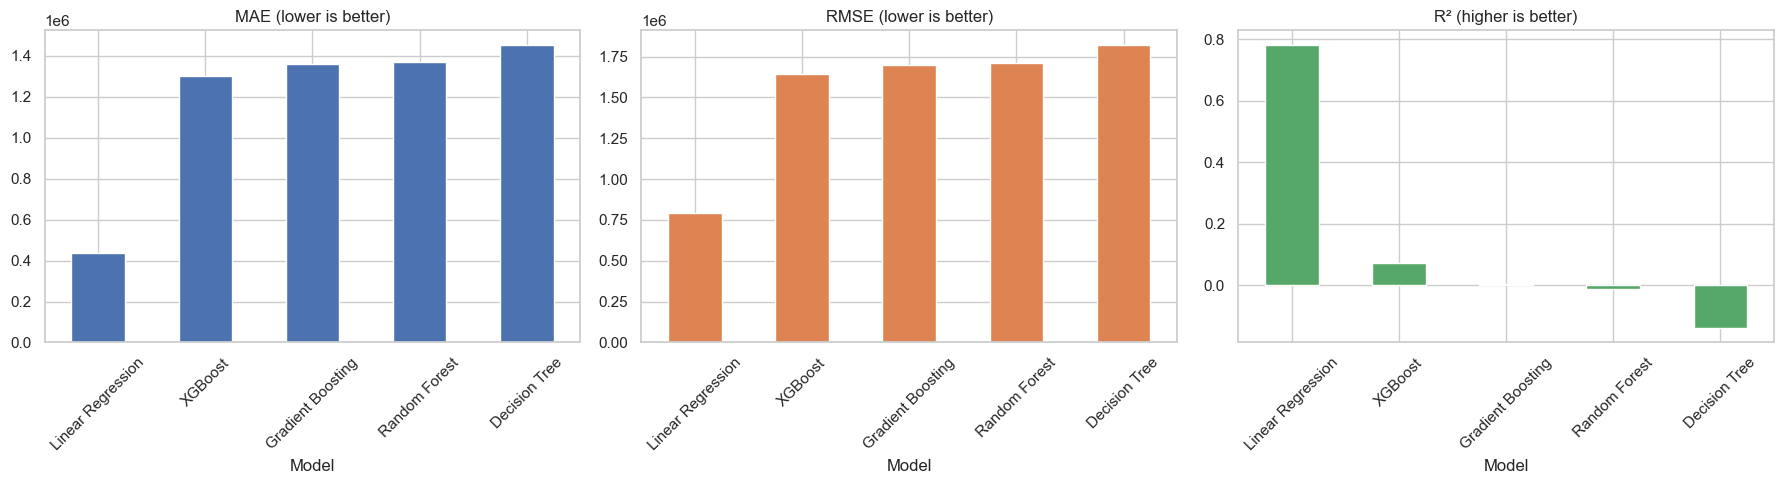

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df['MAE'].plot(kind='bar', ax=axes[0], title='MAE (lower is better)', color='#4C72B0')
results_df['RMSE'].plot(kind='bar', ax=axes[1], title='RMSE (lower is better)', color='#DD8452')
results_df['R2'].plot(kind='bar', ax=axes[2], title='R² (higher is better)', color='#55A868')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

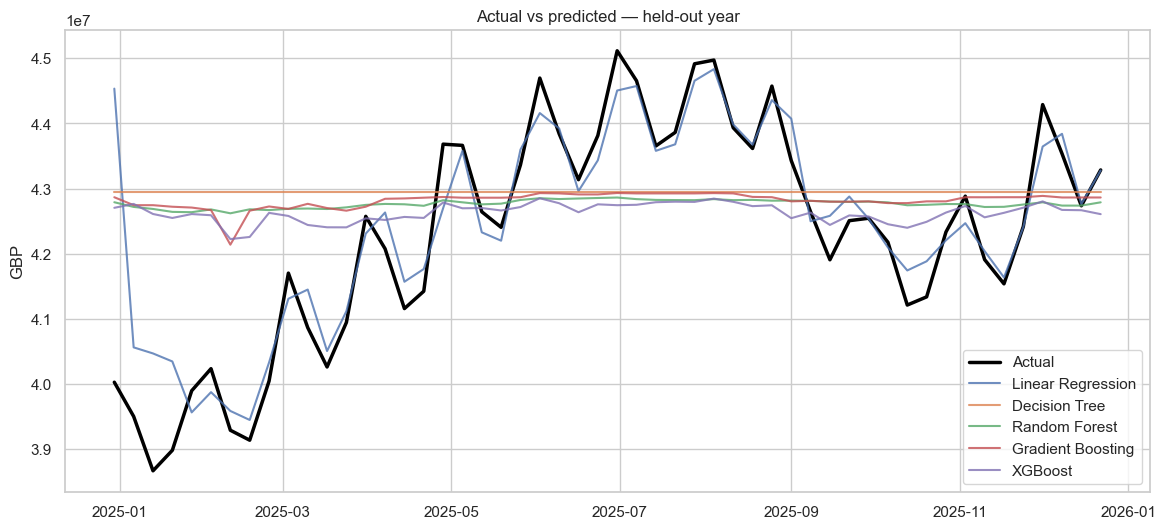

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test, y_test.values, label='Actual', color='black', linewidth=2.5)
for name, model in fitted_models.items():
    ax.plot(dates_test, model.predict(X_test), label=name, alpha=0.8)
ax.set_title('Actual vs predicted — held-out year')
ax.set_ylabel('GBP')
ax.legend()
plt.show()

## 8. What drives each model's predictions

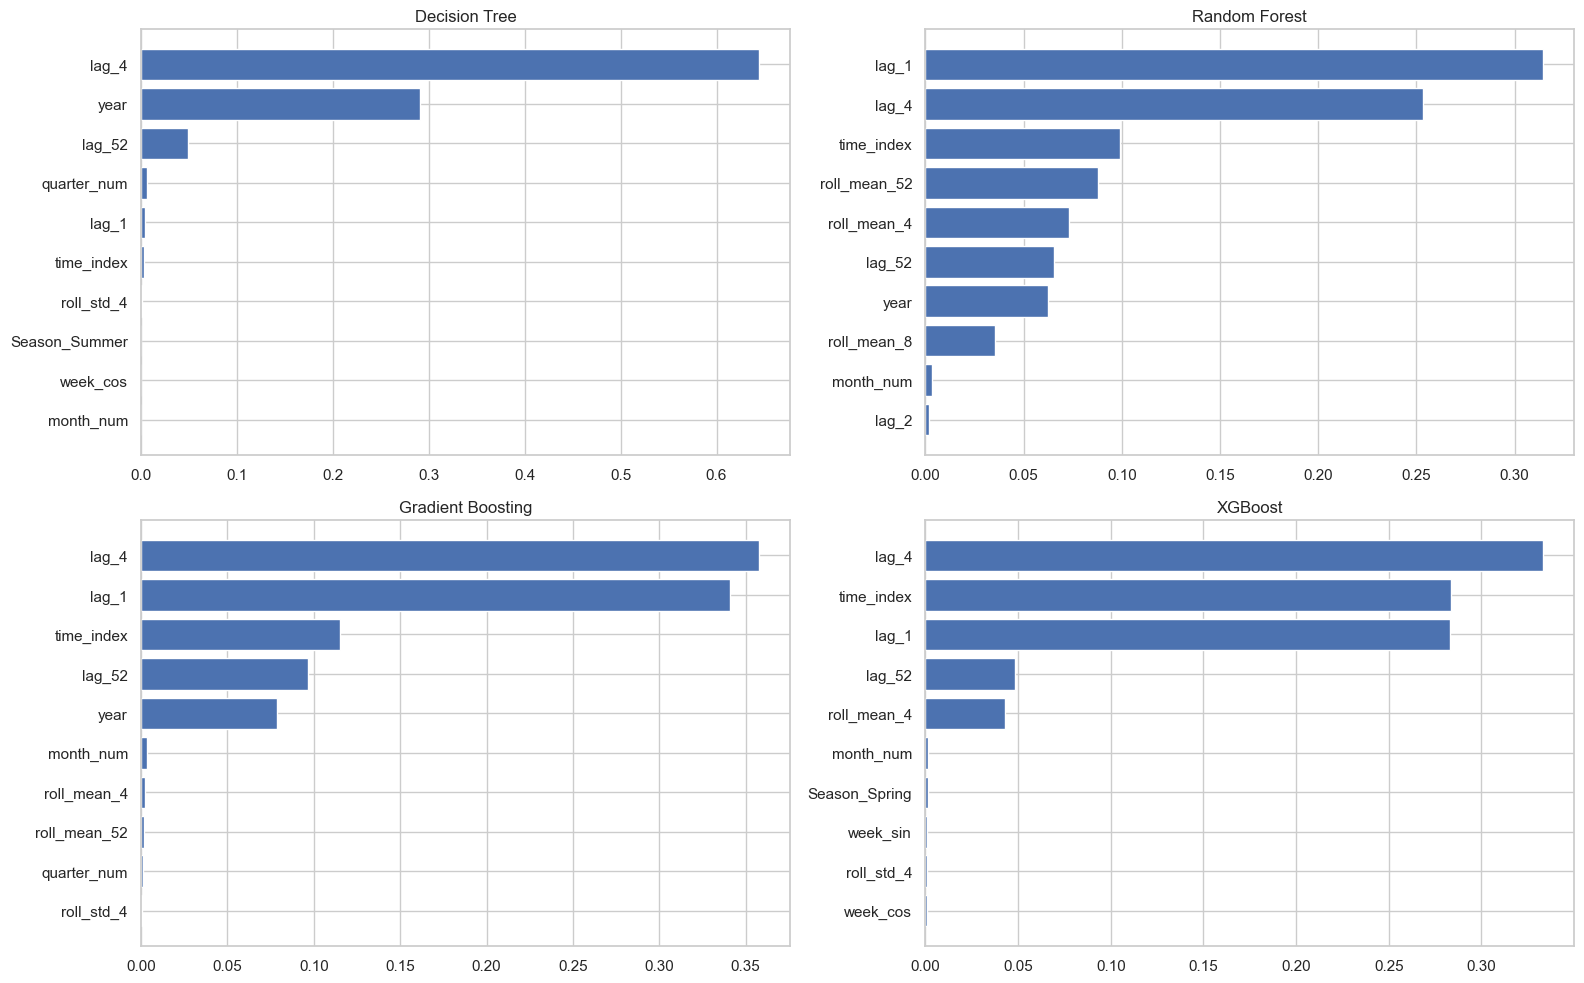

In [17]:
feature_names = NUMERIC_FEATURES + list(
    fitted_models['Random Forest'].named_steps['preprocessor']
    .named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
)

tree_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, name in zip(axes.ravel(), tree_models):
    importances = fitted_models[name].named_steps['model'].feature_importances_
    order = np.argsort(importances)[::-1][:10]
    ax.barh(np.array(feature_names)[order][::-1], importances[order][::-1], color='#4C72B0')
    ax.set_title(name)
plt.tight_layout()
plt.show()

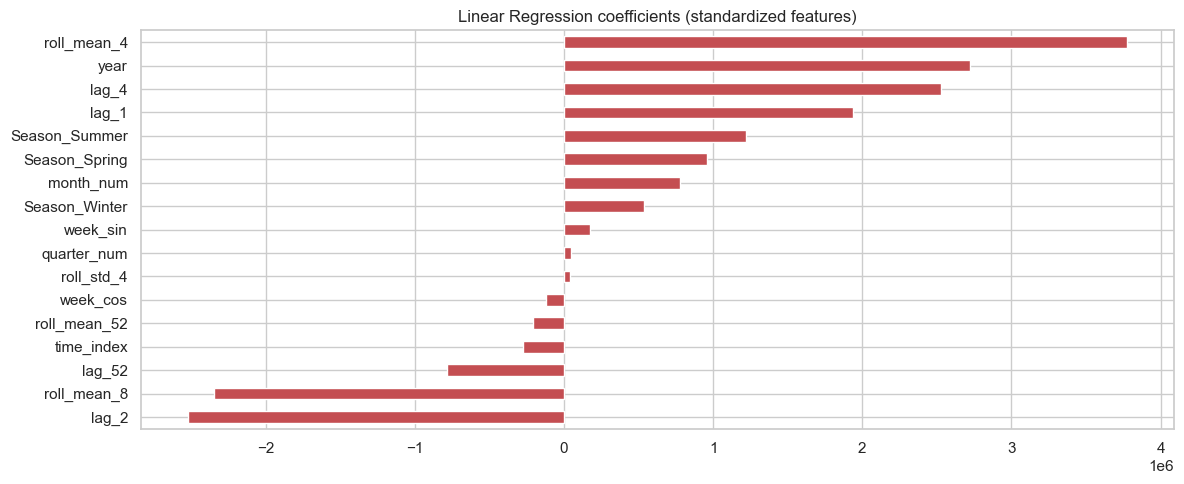

In [18]:
lr_pipe = fitted_models['Linear Regression']
coefs = pd.Series(lr_pipe.named_steps['model'].coef_, index=feature_names).sort_values()
coefs.plot(kind='barh', title='Linear Regression coefficients (standardized features)', color='#C44E52')
plt.tight_layout()
plt.show()

## 9. Can Linear Regression be improved further?

Before turning to fix the tree models' extrapolation problem (sections 10–11), it's worth pushing on the model that already won section 7: can Linear Regression's accuracy improve further — and do the same tricks help the trees too? Two genuinely different kinds of change are tested here, kept deliberately separate:

- **A different regression algorithm** (section 9.1): polynomial regression — a model whose prediction is a curved, not straight-line, function of some inputs.
- **Richer engineered features fed into the exact same algorithm** (section 9.2): extra Fourier harmonics added to the seasonal encoding from section 3.2, still fitted with plain, unmodified Linear Regression.

Both are also tested on the four tree models, not just Linear Regression — that comparison is what tells us whether any gain comes from the *algorithm* or from the *feature*, which turns out to matter a lot.

### 9.1 Polynomial regression

**Hypothesis:** section 7 showed Linear Regression winning because it can extrapolate a trend, but a straight line is still a restrictive shape. Could letting it fit *curvature* — e.g. a quadratic or cubic term on `time_index`, or interaction terms between features — capture the relationship more accurately and reduce error further? `PolynomialFeatures` generates those extra columns (e.g. `time_index²`, `lag_1 × lag_52`) mechanically, and a plain `LinearRegression` fitted on top of them is technically still "linear" in its parameters — the curvature comes entirely from the engineered input columns, not from the fitting algorithm. Four variants are tested against the section 7 baseline: curvature on `time_index` alone (degree 2 and 3), and a full degree-2 expansion of every numeric feature, both unregularized and with Ridge regularization to control the resulting parameter count.

In [19]:
poly_results = []

# (a) curvature on the trend term alone -- rest of the feature set unchanged
for deg in [2, 3]:
    pre_poly_time = ColumnTransformer([
        ('time_poly', PolynomialFeatures(degree=deg, include_bias=False), ['time_index']),
        ('num', StandardScaler(), [c for c in NUMERIC_FEATURES if c != 'time_index']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ])
    pipe = Pipeline([('preprocessor', pre_poly_time), ('model', LinearRegression())])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    poly_results.append({
        'Variant': f'time_index only, degree {deg}',
        'MAE': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred),
    })

# (b) full degree-2 expansion of every numeric feature, unregularized
poly_pre_full = ColumnTransformer([
    ('num', Pipeline([('scale', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False))]), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_FEATURES),
])
pipe = Pipeline([('preprocessor', poly_pre_full), ('model', LinearRegression())])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
poly_results.append({'Variant': 'Degree-2, all features, unregularized',
                      'MAE': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred)})

# (c) same degree-2 expansion, Ridge-regularized to control the parameter explosion
pipe = Pipeline([('preprocessor', poly_pre_full), ('model', Ridge(alpha=10.0))])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
poly_results.append({'Variant': 'Degree-2, all features, + Ridge (alpha=10)',
                      'MAE': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred)})

# section 7 baseline, for reference
baseline_pred = fitted_models['Linear Regression'].predict(X_test)
poly_results.append({'Variant': 'Plain Linear Regression (section 7 baseline)',
                      'MAE': mean_absolute_error(y_test, baseline_pred), 'R2': r2_score(y_test, baseline_pred)})

poly_df = pd.DataFrame(poly_results).set_index('Variant').sort_values('MAE')
poly_df

,MAE,R2
Variant,,
Plain Linear Regression (section 7 baseline),4.367419e+05,0.782464
"time_index only, degree 2",7.808806e+05,0.617366
"time_index only, degree 3",1.103877e+06,0.398466
"Degree-2, all features, + Ridge (alpha=10)",3.522241e+06,-3.319383
"Degree-2, all features, unregularized",1.062334e+07,-1620.611576


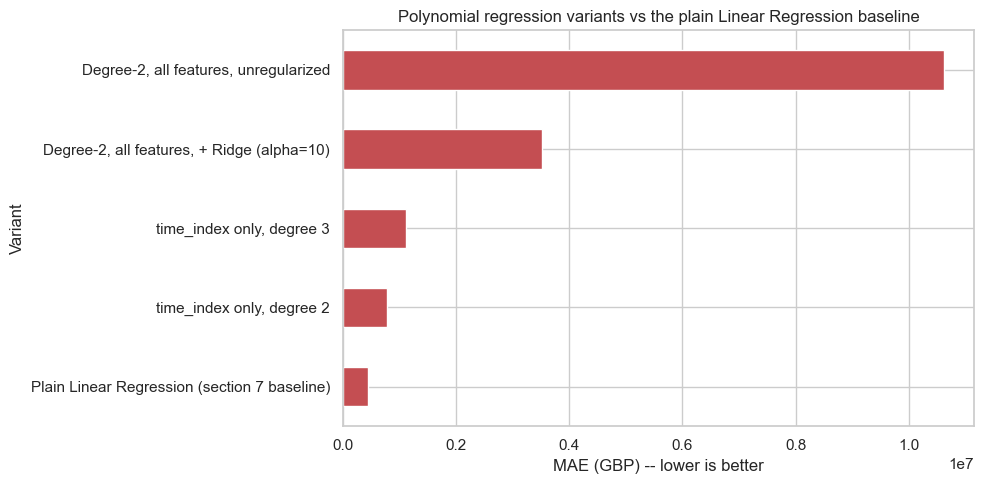

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
poly_df['MAE'].sort_values().plot(kind='barh', color='#C44E52', ax=ax)
ax.set_xlabel('MAE (GBP) -- lower is better')
ax.set_title('Polynomial regression variants vs the plain Linear Regression baseline')
plt.tight_layout()
plt.show()

**Every polynomial variant is worse than plain Linear Regression** — the full-feature degree-2 expansion catastrophically so. Two compounding reasons:

1. **Polynomials extrapolate far worse than a straight line.** A line's slope is constant, so extending it past the training range just keeps going at the same rate — exactly why plain Linear Regression won section 7. A quadratic or cubic's slope keeps *changing*, so once the input (here, a 2025 `time_index` beyond anything seen in training) is outside the training range, the curve can shoot off in whatever direction its fitted curvature points. Section 8 already established this series' true annual growth is a sequence of irregular jumps (0%, +21%, +6%, +17%, +5%), not smooth acceleration — so a quadratic term doesn't find real curvature, it fits *noise* as if it were a curve, then extrapolates that noise forward. That is why `time_index` degree 2 alone already loses to plain linear, and degree 3 loses more.
2. **Expanding every feature to degree 2 creates more parameters than there are rows to estimate them.** 14 numeric features become roughly 119 terms (squares and pairwise interactions) fit on 209 training rows — severely overdetermined. The unregularized version effectively memorises noise (an R² in the thousands-negative is what a spectacularly overfit, badly-extrapolating model looks like); Ridge reins in the coefficient explosion but still can't undo the fact that most of those 119 terms are irrelevant, so it still loses badly to the plain model.

Neither problem is specific to this dataset — both are textbook reasons polynomial regression is a risky default choice for any extrapolation-heavy forecasting problem.

### 9.2 Extra Fourier harmonics

**Hypothesis:** section 3.2 encoded the weekly seasonal cycle with a single sine/cosine pair (`week_sin`, `week_cos`) — mathematically, that can only represent a pure sine wave, one peak and one trough per year. Adding a second and third **harmonic** — `sin`/`cos` at 2× and 3× that frequency — lets the fitted seasonal curve take a richer shape (e.g. a sharper summer peak) while still being a straight-line combination of bounded inputs. This is the crucial difference from 9.1: a Fourier term is always between −1 and 1 no matter how far into the future it's evaluated, so unlike a polynomial time trend, adding harmonics carries no extrapolation risk. This technique has a name — **harmonic regression** (or Fourier series regression) — and it's the same idea Facebook's Prophet library uses for seasonality, not something specific to this notebook.

Unlike 9.1, this is tested on **all five models**, using the same tuning approach as section 7 (`RandomizedSearchCV` + `TimeSeriesSplit`), to see whether richer seasonal features help only Linear Regression or the trees too.

In [21]:
def engineer_features_harmonics(data, harmonics=1):
    """Same idea as engineer_features (section 4), but with `harmonics` sin/cos pairs instead of
    exactly one, so the seasonal curve can be more than a single sine wave. Still bounded between
    -1 and 1 regardless of harmonics count or how far into the future a row is -- unlike the
    polynomial time trend in 9.1, this is always safe to extrapolate."""
    d = data.sort_values('Week Start').reset_index(drop=True).copy()
    d['time_index'] = np.arange(len(d))
    for h in range(1, harmonics + 1):
        d[f'week_sin{h}'] = np.sin(2 * np.pi * h * d['ISO Week'] / 52)
        d[f'week_cos{h}'] = np.cos(2 * np.pi * h * d['ISO Week'] / 52)
    d['month_num'] = d['Week Start'].dt.month
    d['quarter_num'] = d['Week Start'].dt.quarter
    d['year'] = d['ISO Year']
    target = d['Estimated Weekly Sales GBP']
    d['lag_1'] = target.shift(1)
    d['lag_2'] = target.shift(2)
    d['lag_4'] = target.shift(4)
    d['lag_52'] = target.shift(52)
    d['roll_mean_4'] = target.shift(1).rolling(4).mean()
    d['roll_std_4'] = target.shift(1).rolling(4).std()
    d['roll_mean_8'] = target.shift(1).rolling(8).mean()
    d['roll_mean_52'] = target.shift(1).rolling(52).mean()
    return d

In [22]:
from sklearn.base import clone

harmonics_results = []

for harmonics in [1, 2, 3]:
    feat_h = engineer_features_harmonics(df, harmonics).dropna().reset_index(drop=True)
    num_h = (['time_index']
             + [f'week_sin{h}' for h in range(1, harmonics + 1)]
             + [f'week_cos{h}' for h in range(1, harmonics + 1)]
             + ['month_num', 'quarter_num', 'year', 'lag_1', 'lag_2', 'lag_4', 'lag_52',
                'roll_mean_4', 'roll_std_4', 'roll_mean_8', 'roll_mean_52'])
    X_h = feat_h[num_h + CATEGORICAL_FEATURES]
    y_h = feat_h[TARGET]
    X_h_train, X_h_test = X_h.iloc[:-TEST_SIZE], X_h.iloc[-TEST_SIZE:]
    y_h_train, y_h_test = y_h.iloc[:-TEST_SIZE], y_h.iloc[-TEST_SIZE:]
    pre_h = ColumnTransformer([
        ('num', StandardScaler(), num_h),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ])

    for name, (estimator, grid) in model_specs.items():
        pipe = Pipeline([('preprocessor', pre_h), ('model', clone(estimator))])  # clone: never refit the shared model_specs object in place
        if grid:
            search = RandomizedSearchCV(pipe, grid, n_iter=15, cv=tscv,
                                         scoring='neg_mean_absolute_error',
                                         random_state=RANDOM_STATE, n_jobs=-1)
            search.fit(X_h_train, y_h_train)
            best_pipe = search.best_estimator_
        else:
            best_pipe = pipe.fit(X_h_train, y_h_train)
        pred = best_pipe.predict(X_h_test)
        harmonics_results.append({
            'Model': name, 'Harmonics': harmonics,
            'MAE': mean_absolute_error(y_h_test, pred),
            'RMSE': np.sqrt(mean_squared_error(y_h_test, pred)),
            'MAPE (%)': mape(y_h_test, pred),
            'R2': r2_score(y_h_test, pred),
        })

harmonics_df = pd.DataFrame(harmonics_results)
_model_order = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
harmonics_df['Model'] = pd.Categorical(harmonics_df['Model'], categories=_model_order, ordered=True)
harmonics_summary = harmonics_df.set_index(['Model', 'Harmonics']).sort_index()
harmonics_summary.round(2)

MAE        RMSE  MAPE (%)    R2
Model             Harmonics                                        
Linear Regression 1           436741.94   794550.47      1.06  0.78
                  2           414355.72   745217.50      1.00  0.81
                  3           409122.62   765502.40      0.99  0.80
Decision Tree     1          1450190.13  1819380.92      3.51 -0.14
                  2          1436583.13  1793156.02      3.47 -0.11
                  3          1450190.13  1819380.92      3.51 -0.14
Random Forest     1          1370046.43  1713000.29      3.30 -0.01
                  2          1370547.86  1712103.73      3.30 -0.01
                  3          1360961.67  1696535.48      3.28  0.01
Gradient Boosting 1          1358714.88  1699368.75      3.28  0.00
                  2          1350309.48  1682608.84      3.26  0.02
                  3          1363189.32  1698015.47      3.29  0.01
XGBoost           1          1298701.72  1641959.78      3.13  0.07
                  2          1302645.80  1647805.07      3.14  0.06
                  3          1280508.21  1599282.38      3.08  0.12

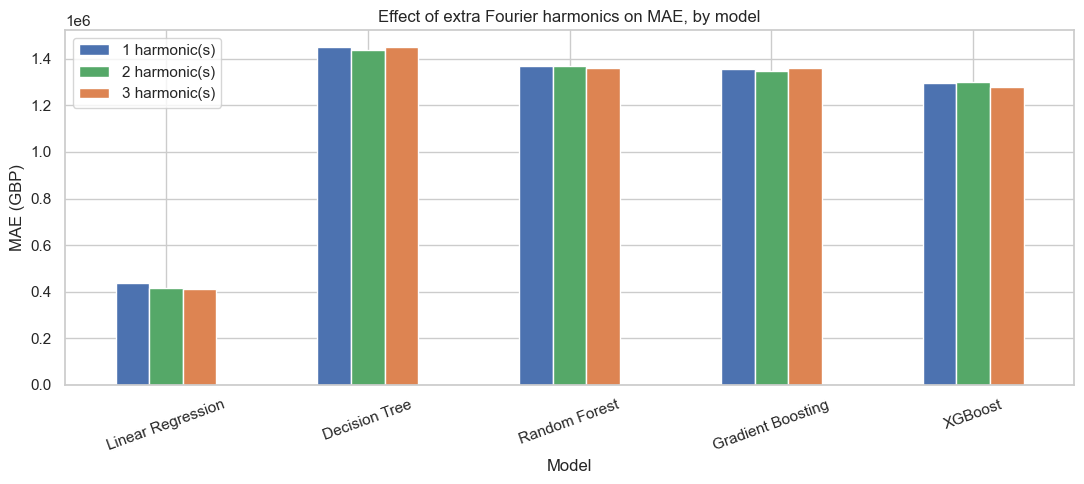

In [23]:
harmonics_mae = harmonics_df.pivot(index='Model', columns='Harmonics', values='MAE')
harmonics_mae = harmonics_mae.reindex(_model_order)
harmonics_mae.columns = [f'{h} harmonic(s)' for h in harmonics_mae.columns]

fig, ax = plt.subplots(figsize=(11, 5))
harmonics_mae.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#DD8452'])
ax.set_ylabel('MAE (GBP)')
ax.set_title('Effect of extra Fourier harmonics on MAE, by model')
ax.legend(title=None)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

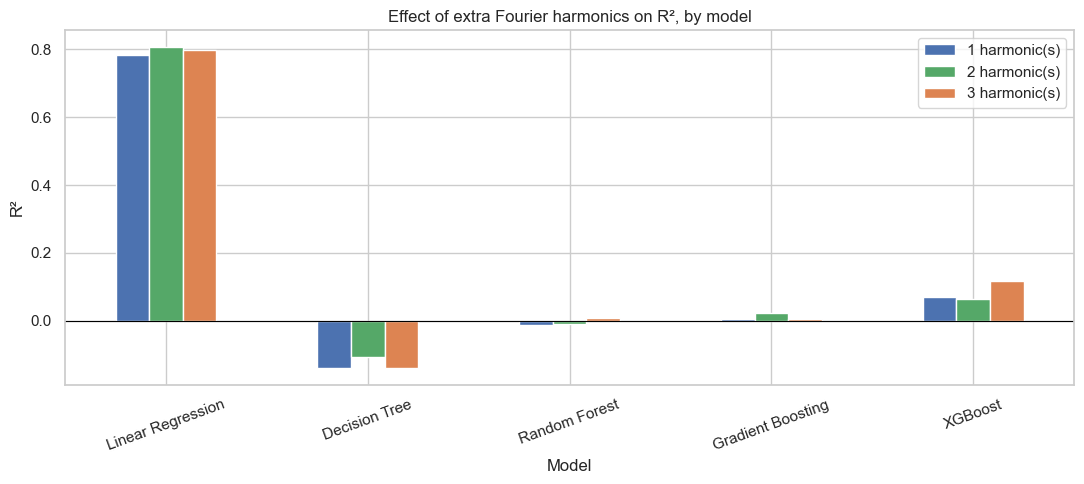

In [24]:
harmonics_r2 = harmonics_df.pivot(index='Model', columns='Harmonics', values='R2')
harmonics_r2 = harmonics_r2.reindex(_model_order)
harmonics_r2.columns = [f'{h} harmonic(s)' for h in harmonics_r2.columns]

fig, ax = plt.subplots(figsize=(11, 5))
harmonics_r2.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#DD8452'])
ax.set_ylabel('R²')
ax.set_title('Effect of extra Fourier harmonics on R², by model')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title=None)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The two model families respond completely differently, and the reason ties directly back to section 5's description of how each one works:

- **Linear Regression improves, modestly but really**, as harmonics increase — it was structurally stuck fitting one rigid sine wave with a single harmonic, and additional harmonics let it represent a non-sinusoidal seasonal shape (still as a straight-line combination of bounded terms, so with no extrapolation risk, unlike 9.1).
- **The tree models barely move, in either direction** — the changes are small and don't consistently go one way, which is the signature of noise, not a real effect. This makes sense given how trees work (section 5.2–5.5): given `week_sin` and `week_cos` as two coordinates, a tree can already carve the 52-week cycle into as many small regions as the data supports and approximate almost any seasonal shape that way — it doesn't need extra harmonics to do what Linear Regression needed them for.

So the two experiments in this section teach different lessons about the two model families: the *feature* change (harmonics) helps whichever model is otherwise too rigid to represent seasonal shape on its own (Linear Regression), and does nothing for a model whose structure already has that flexibility built in (trees). The trees' real bottleneck was never seasonal shape — it's the extrapolation ceiling investigated next, and no amount of feature engineering touches that.

The two Linear Regression + harmonics variants above are carried forward into the notebook's final model comparison (`final_comparison_df`, section 12) and conclusions (section 13), labelled `Linear Regression (2 harmonics)` and `Linear Regression (3 harmonics)`, so they're compared directly against every other model and experiment in this notebook — not left sitting only in this section.

In [25]:
results_harmonics_df = (
    harmonics_df[(harmonics_df['Model'] == 'Linear Regression') & (harmonics_df['Harmonics'] > 1)]
    .assign(Model=lambda d: d['Harmonics'].map(lambda h: f'Linear Regression ({h} harmonics)'))
    .set_index('Model')[['MAE', 'RMSE', 'MAPE (%)', 'R2']]
)
results_harmonics_df

,MAE,RMSE,MAPE (%),R2
Model,,,,
Linear Regression (2 harmonics),414355.723984,745217.501976,1.002717,0.808638
Linear Regression (3 harmonics),409122.622150,765502.398396,0.990621,0.798079


**Where this leaves the two model families going into the next sections:** Linear Regression has now been pushed about as far as feature and functional-form changes can take it — harmonics gave a real if modest gain, polynomial terms actively hurt. The tree models, meanwhile, are unmoved by either change, which confirms their problem was never about feature richness or seasonal shape. Sections 10–11 dig into what their problem actually is, and what does (and doesn't) fix it.

## 10. Attempt 1: predict the year-over-year ratio instead of the level

The diagnosis above suggests a fix worth testing: trees can't output a GBP level above the max they trained on, but they should be fine at predicting a **bounded** quantity. The year-over-year ratio `y_t / y_{t-52}` (this week vs. the same week last year) stays inside roughly **0.99–1.22** across 2020–2025, and 2025's actual ratios (~1.05 on average) sit comfortably inside that historical band even though the GBP level itself is a new high. The hypothesis: predict the ratio and reconstruct `y_hat = lag_52_actual × ratio_hat`, so the trees never have to extrapolate.

Same features, same `preprocessor`, same `TimeSeriesSplit` + `RandomizedSearchCV` tuning, same split — only the *target* changes, and only for the four tree-based models.

In [26]:
assert (featured['lag_52'] > 0).all(), 'lag_52 must be strictly positive to use as a ratio denominator'

y_ratio = featured[TARGET] / featured['lag_52']
y_ratio_train, y_ratio_test = y_ratio.iloc[:-TEST_SIZE], y_ratio.iloc[-TEST_SIZE:]
lag52_test = X_test['lag_52']

print('YoY ratio range in train:', round(y_ratio_train.min(), 3), 'to', round(y_ratio_train.max(), 3))
print('YoY ratio range in test: ', round(y_ratio_test.min(), 3), 'to', round(y_ratio_test.max(), 3))

YoY ratio range in train: 0.994 to 1.215
YoY ratio range in test:  1.037 to 1.048


In [27]:
tree_only_specs = {name: spec for name, spec in model_specs.items() if name != 'Linear Regression'}

fitted_models_ratio = {}
results_ratio = []

for name, (estimator, param_grid) in tree_only_specs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', estimator)])

    search = RandomizedSearchCV(
        pipe, param_grid, n_iter=15, cv=tscv,
        scoring='neg_mean_absolute_error',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_ratio_train)
    best_pipe = search.best_estimator_
    print(f"{name} (ratio target) best params: {search.best_params_}")

    ratio_pred = best_pipe.predict(X_test)
    y_pred = ratio_pred * lag52_test.values

    results_ratio.append({
        'Model': f'{name} (ratio target)',
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE (%)': mape(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
    })
    fitted_models_ratio[name] = best_pipe

results_ratio_df = pd.DataFrame(results_ratio).set_index('Model').sort_values('MAE')
results_ratio_df

Decision Tree (ratio target) best params: {'model__min_samples_leaf': 2, 'model__max_depth': 3}
Random Forest (ratio target) best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Gradient Boosting (ratio target) best params: {'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.1}
XGBoost (ratio target) best params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.1}


,MAE,RMSE,MAPE (%),R2
Model,,,,
Random Forest (ratio target),4.745747e+06,4.751214e+06,11.215074,-6.778535
XGBoost (ratio target),4.754254e+06,4.760459e+06,11.233858,-6.808834
Decision Tree (ratio target),4.807834e+06,4.811636e+06,11.365270,-6.977635
Gradient Boosting (ratio target),4.808614e+06,4.815075e+06,11.361498,-6.989042


In [28]:
combined_results_df = pd.concat([results_df, results_ratio_df]).sort_values('MAE')
combined_results_df

,MAE,RMSE,MAPE (%),R2
Model,,,,
Linear Regression,4.367419e+05,7.945505e+05,1.058673,0.782464
XGBoost,1.298702e+06,1.641960e+06,3.125980,0.071004
Gradient Boosting,1.358715e+06,1.699369e+06,3.279842,0.004907
Random Forest,1.370046e+06,1.713000e+06,3.303970,-0.011122
Decision Tree,1.450190e+06,1.819381e+06,3.507891,-0.140607
Random Forest (ratio target),4.745747e+06,4.751214e+06,11.215074,-6.778535
XGBoost (ratio target),4.754254e+06,4.760459e+06,11.233858,-6.808834
Decision Tree (ratio target),4.807834e+06,4.811636e+06,11.365270,-6.977635
Gradient Boosting (ratio target),4.808614e+06,4.815075e+06,11.361498,-6.989042


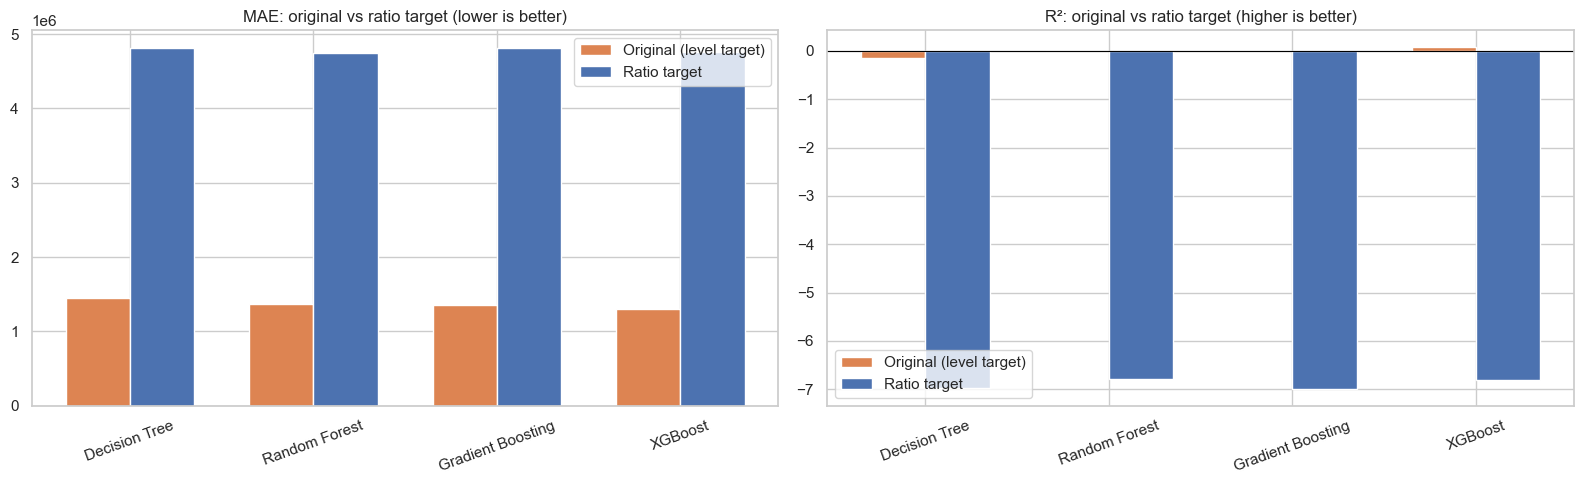

In [29]:
tree_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
orig_mae = [results_df.loc[n, 'MAE'] for n in tree_names]
ratio_mae = [results_ratio_df.loc[f'{n} (ratio target)', 'MAE'] for n in tree_names]
orig_r2 = [results_df.loc[n, 'R2'] for n in tree_names]
ratio_r2 = [results_ratio_df.loc[f'{n} (ratio target)', 'R2'] for n in tree_names]

x = np.arange(len(tree_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(x - width / 2, orig_mae, width, label='Original (level target)', color='#DD8452')
axes[0].bar(x + width / 2, ratio_mae, width, label='Ratio target', color='#4C72B0')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tree_names, rotation=20)
axes[0].set_title('MAE: original vs ratio target (lower is better)')
axes[0].legend()

axes[1].bar(x - width / 2, orig_r2, width, label='Original (level target)', color='#DD8452')
axes[1].bar(x + width / 2, ratio_r2, width, label='Ratio target', color='#4C72B0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tree_names, rotation=20)
axes[1].set_title('R²: original vs ratio target (higher is better)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

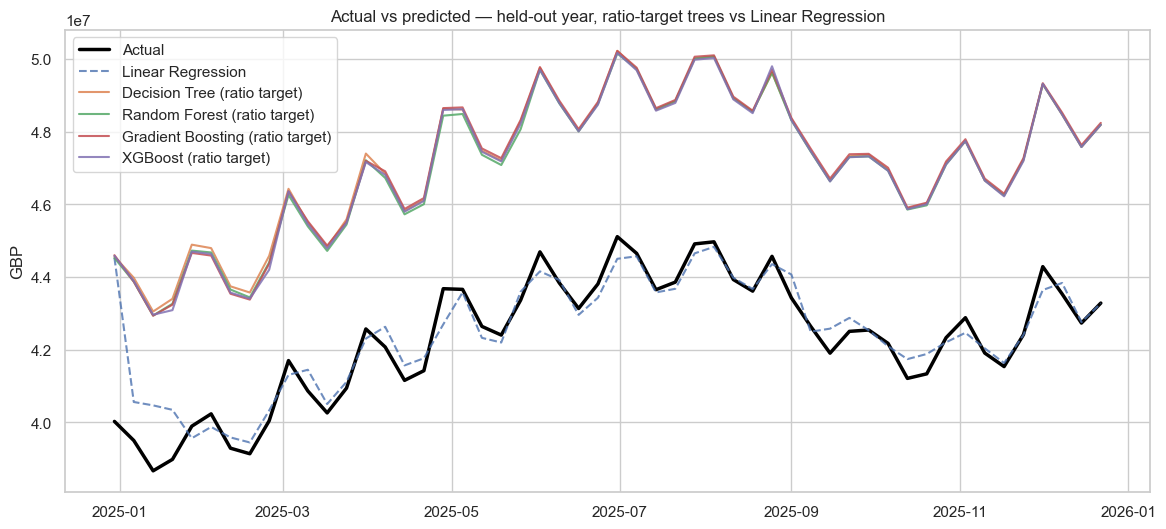

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test, y_test.values, label='Actual', color='black', linewidth=2.5)
ax.plot(dates_test, fitted_models['Linear Regression'].predict(X_test),
        label='Linear Regression', alpha=0.8, linestyle='--')
for name, model in fitted_models_ratio.items():
    y_pred = model.predict(X_test) * lag52_test.values
    ax.plot(dates_test, y_pred, label=f'{name} (ratio target)', alpha=0.85)
ax.set_title('Actual vs predicted — held-out year, ratio-target trees vs Linear Regression')
ax.set_ylabel('GBP')
ax.legend()
plt.show()

**This hypothesis was wrong — the ratio-target models are dramatically worse than the original level-target trees**, not better (MAE ~4.7–4.8M vs. ~1.3–1.4M, R² around −7). Worth understanding exactly why, since it's a more general lesson than this dataset:

Inspecting the fitted models' predictions shows every 2025 test row gets almost the same predicted ratio (~1.16–1.17) — which is 2024's average year-over-year growth rate, not 2025's (~1.05). The trees aren't extrapolating on the *ratio* (it's in-range, as designed); they're using `lag_52` and `roll_mean_52` — which encode the *absolute GBP magnitude* of a year ago — as an implicit lookup key for *which year this is*, because each year's sales sit at a distinctive magnitude. A test row's `lag_52` (2024's actual sales) sits right at the top edge of the magnitudes seen in training, so the tree assigns it the growth rate that magnitude bucket was associated with historically (2024's own growth rate, +16.7%) — not the true, different rate that year turned out to have (2025's +4.8%). Removing `year` from the feature set doesn't fix this, because `lag_52` alone still serves as a year fingerprint.

Two follow-up experiments (not kept in this notebook, but run to confirm) reinforce the same conclusion: giving the trees the *actual* `Annual Benchmark GBP` value directly doesn't help, because that number is itself a new high in 2025 — same extrapolation trap, one column over. Giving them the *true, in-range* benchmark growth ratio as a known input doesn't help either, because reconstructing the GBP level from it requires learning `lag_52 × growth_rate`, a multiplicative interaction that axis-aligned tree splits can't represent well from ~200 training rows.

The deeper issue: this series' year-to-year growth is a sequence of independent market-value jumps (see `Annual_Benchmarks`: +0%, +21%, +6%, +17%, +5%) with no autocorrelation — nothing in the weekly history predicts *how big* the next jump will be. No amount of feature engineering fixes that; it's exogenous information the model doesn't have. (This also means Linear Regression's earlier win is likely partly luck — its single trend line, fit as an average slope across five very different annual jumps, happened to extrapolate close to 2025's smaller-than-average jump. Don't over-trust that R²=0.78 as a repeatable skill either.)

## 11. Attempt 2: walk-forward retraining — what actually works

If the model can't predict a year's growth jump from a standing start, the fix is to stop asking it to. Instead of freezing the model at the end of 2024 and forecasting all 52 weeks of 2025 blind, **retrain periodically as real 2025 weeks are observed** (an expanding window, refit every 4 weeks). Each refit's training set now includes actual, current-year sales — so predicting the *next* 4 weeks is short-horizon interpolation, not a blind 12-month extrapolation. This is also standard real-world practice: a deployed demand model gets retrained on a schedule as new data arrives, not frozen for a year.

This reuses the hyperparameters already tuned in section 6–7 (via `clone()` on the fitted section-7 pipelines) rather than re-running `RandomizedSearchCV` at every refit — cheap and defensible since a production retraining job would typically keep its tuned hyperparameters fixed and just refit on fresh data.

In [31]:
from sklearn.base import clone

WALK_STEP = 4  # retrain every 4 weeks as new actuals arrive
train_end = len(featured) - TEST_SIZE

walk_forward_results = []
walk_forward_preds = {}

for name in ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']:
    base_pipe = fitted_models[name]  # reuse the hyperparameters tuned in section 7
    all_pred, all_actual, all_dates = [], [], []
    for start in range(train_end, len(featured), WALK_STEP):
        end = min(start + WALK_STEP, len(featured))
        pipe = clone(base_pipe)
        pipe.fit(X.iloc[:start], y.iloc[:start])
        pred = pipe.predict(X.iloc[start:end])
        all_pred.extend(pred)
        all_actual.extend(y.iloc[start:end].values)
        all_dates.extend(dates.iloc[start:end])

    all_pred = np.array(all_pred)
    all_actual = np.array(all_actual)
    walk_forward_preds[name] = (all_dates, all_actual, all_pred)
    walk_forward_results.append({
        'Model': f'{name} (walk-forward retrain)',
        'MAE': mean_absolute_error(all_actual, all_pred),
        'RMSE': np.sqrt(mean_squared_error(all_actual, all_pred)),
        'MAPE (%)': mape(all_actual, all_pred),
        'R2': r2_score(all_actual, all_pred),
    })

results_walkforward_df = pd.DataFrame(walk_forward_results).set_index('Model').sort_values('MAE')
results_walkforward_df

,MAE,RMSE,MAPE (%),R2
Model,,,,
Gradient Boosting (walk-forward retrain),630223.953587,1.106783e+06,1.531242,0.577902
Random Forest (walk-forward retrain),683290.947507,1.147580e+06,1.654629,0.546210
XGBoost (walk-forward retrain),719333.620741,1.121997e+06,1.737441,0.566217
Decision Tree (walk-forward retrain),973851.910528,1.411917e+06,2.359834,0.313079


In [32]:
final_comparison_df = pd.concat([results_df, results_harmonics_df, results_ratio_df, results_walkforward_df]).sort_values('MAE')
final_comparison_df

,MAE,RMSE,MAPE (%),R2
Model,,,,
Linear Regression (3 harmonics),4.091226e+05,7.655024e+05,0.990621,0.798079
Linear Regression (2 harmonics),4.143557e+05,7.452175e+05,1.002717,0.808638
Linear Regression,4.367419e+05,7.945505e+05,1.058673,0.782464
Gradient Boosting (walk-forward retrain),6.302240e+05,1.106783e+06,1.531242,0.577902
Random Forest (walk-forward retrain),6.832909e+05,1.147580e+06,1.654629,0.546210
XGBoost (walk-forward retrain),7.193336e+05,1.121997e+06,1.737441,0.566217
Decision Tree (walk-forward retrain),9.738519e+05,1.411917e+06,2.359834,0.313079
XGBoost,1.298702e+06,1.641960e+06,3.125980,0.071004
Gradient Boosting,1.358715e+06,1.699369e+06,3.279842,0.004907


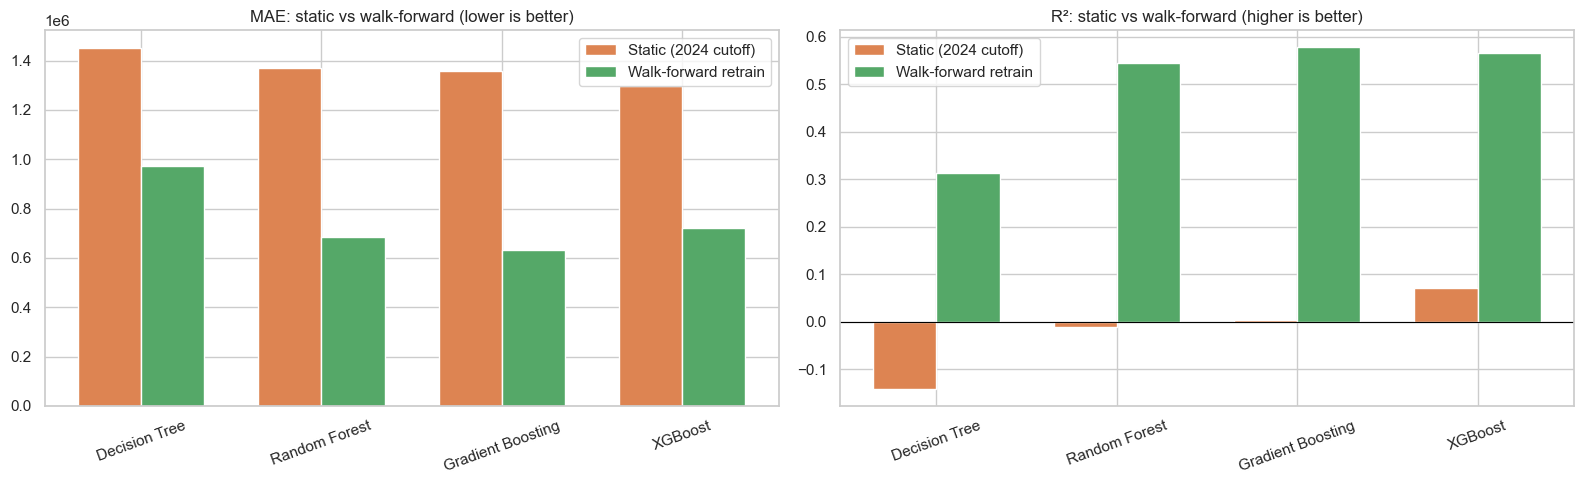

In [33]:
tree_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']
static_mae = [results_df.loc[n, 'MAE'] for n in tree_names]
wf_mae = [results_walkforward_df.loc[f'{n} (walk-forward retrain)', 'MAE'] for n in tree_names]
static_r2 = [results_df.loc[n, 'R2'] for n in tree_names]
wf_r2 = [results_walkforward_df.loc[f'{n} (walk-forward retrain)', 'R2'] for n in tree_names]

x = np.arange(len(tree_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(x - width / 2, static_mae, width, label='Static (2024 cutoff)', color='#DD8452')
axes[0].bar(x + width / 2, wf_mae, width, label='Walk-forward retrain', color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tree_names, rotation=20)
axes[0].set_title('MAE: static vs walk-forward (lower is better)')
axes[0].legend()

axes[1].bar(x - width / 2, static_r2, width, label='Static (2024 cutoff)', color='#DD8452')
axes[1].bar(x + width / 2, wf_r2, width, label='Walk-forward retrain', color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tree_names, rotation=20)
axes[1].set_title('R²: static vs walk-forward (higher is better)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

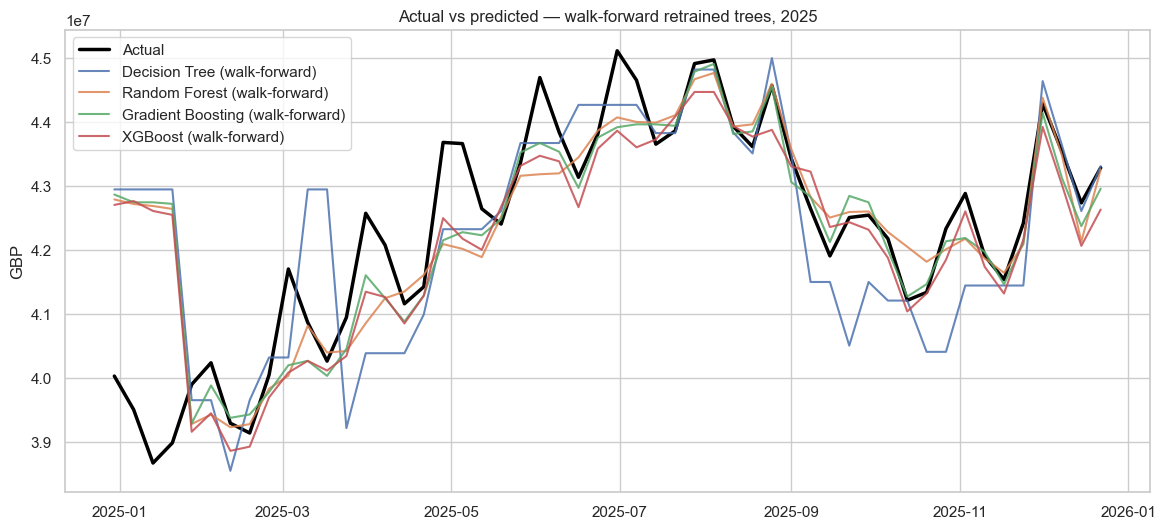

In [34]:
fig, ax = plt.subplots(figsize=(14, 6))
ref_dates, ref_actual, _ = walk_forward_preds['Random Forest']
ax.plot(ref_dates, ref_actual, label='Actual', color='black', linewidth=2.5)
for name, (wf_dates, _, wf_pred) in walk_forward_preds.items():
    ax.plot(wf_dates, wf_pred, label=f'{name} (walk-forward)', alpha=0.85)
ax.set_title('Actual vs predicted — walk-forward retrained trees, 2025')
ax.set_ylabel('GBP')
ax.legend()
plt.show()

Walk-forward retraining closes most of the gap: every tree model's MAE drops substantially and R² moves from at-or-below zero into solidly positive territory (see `final_comparison_df` above for the exact run's numbers). It doesn't fully catch Linear Regression's static-split score, and that's expected — the first 4-week block of 2025 is still a blind guess in both approaches, and only the *later* blocks benefit from having seen real 2025 data. The trade-off is real too: walk-forward evaluation isn't a true one-shot 52-week-ahead forecast anymore, it's a rolling short-horizon forecast that assumes a retraining cadence — a fair comparison only if that cadence is actually deployable in practice (it is here: refitting these small models takes seconds).

## 12. Save fitted pipelines + comparison table

The saved tree-model artifacts are the **walk-forward-final** versions — each tree pipeline refit one last time on *all* available history (train + the held-out 2025 test weeks), which is what a walk-forward retraining process naturally leaves you with: the most current model, ready for the next real out-of-sample week. `Linear Regression` is saved as originally fit (static split). The `*_ratio_target.joblib` pipelines from the abandoned Attempt 1 are **not** saved — they predict a ratio that reconstructs to a badly biased GBP estimate (see section 10's postmortem) and would be a footgun to reload later.

In [35]:
joblib.dump(fitted_models['Linear Regression'], f'{MODELS_DIR}/linear_regression.joblib')

final_walkforward_models = {}
for name in ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']:
    pipe = clone(fitted_models[name])
    pipe.fit(X, y)  # refit on all available history, as a walk-forward process would
    final_walkforward_models[name] = pipe
    fname = name.lower().replace(' ', '_') + '_walkforward_final'
    joblib.dump(pipe, f'{MODELS_DIR}/{fname}.joblib')

final_comparison_df.to_csv(f'{OUTPUTS_DIR}/model_comparison.csv')
print(f'Saved {1 + len(final_walkforward_models)} fitted pipelines to {MODELS_DIR}/ '
      f'and the full comparison table (including the abandoned ratio-target attempt) to {OUTPUTS_DIR}/model_comparison.csv')

Saved 5 fitted pipelines to ../models_extended/ and the full comparison table (including the abandoned ratio-target attempt) to ../outputs_extended/model_comparison.csv


## 13. Conclusions

Full results from this run, ranked by MAE (`final_comparison_df`):

| Model | MAE (GBP) | R² |
|---|---|---|
| **Linear Regression (3 harmonics)** | **409k** | **0.80** |
| **Linear Regression (2 harmonics)** | **414k** | **0.81** |
| Linear Regression (1 harmonic, section 7 baseline) | 437k | 0.78 |
| Gradient Boosting (walk-forward retrain) | 630k | 0.58 |
| Random Forest (walk-forward retrain) | 683k | 0.55 |
| XGBoost (walk-forward retrain) | 719k | 0.57 |
| Decision Tree (walk-forward retrain) | 974k | 0.31 |
| XGBoost (static, 2024 cutoff) | 1.30M | 0.07 |
| Gradient Boosting (static) | 1.36M | 0.00 |
| Random Forest (static) | 1.37M | −0.01 |
| Decision Tree (static) | 1.45M | −0.14 |
| Random Forest (ratio target) | 4.75M | −6.78 |
| XGBoost (ratio target) | 4.75M | −6.81 |
| Decision Tree (ratio target) | 4.81M | −6.98 |
| Gradient Boosting (ratio target) | 4.81M | −6.99 |

**Polynomial regression variants (section 9.1) are omitted from this table** — all four lost to the plain Linear Regression baseline (worst: R² ≈ −1621 for the unregularized full degree-2 expansion), so none belong in a ranking of viable models. See section 9.1 for their numbers and why each one failed.

**Direct answer to “is there a way to better the tree-based models' results?”: yes, but not the way it was first attempted.**

- **What failed:** predicting the year-over-year ratio instead of the raw level made every tree model dramatically *worse* (R² around −7, vs. −0.14–0.07 for the naive static-split trees). The trees used `lag_52`'s magnitude as an implicit lookup for *which year* a row belonged to, and copied that year's historical growth rate onto 2025 — which had a genuinely different, unpredictable growth rate. Section 10's postmortem walks through the two follow-up checks (feeding in the true benchmark value, then the true benchmark growth ratio) that confirmed this isn't fixable with more feature engineering: the annual growth jump is exogenous information with no autocorrelated precursor in the weekly series.
- **What worked for the trees:** walk-forward retraining (expanding window, refit every 4 weeks through 2025) cut every tree model's MAE by roughly half to two-thirds and pushed R² from at-or-below zero to +0.31–+0.58. Gradient Boosting (walk-forward) came closest to Linear Regression's static score. This works because retraining shortens the extrapolation horizon to about a month instead of a full year — once a model has seen a few real 2025 weeks, predicting the next few is interpolation, not a blind guess at an unprecedented growth rate.
- **What worked for Linear Regression:** extra Fourier harmonics (section 9.2) — letting the seasonal curve be more than a single sine wave — shaved MAE from £437k down to £414k (2 harmonics) and £409k (3 harmonics), and are now the two best-performing configurations in this entire notebook. Polynomial terms on the trend (section 9.1), by contrast, made Linear Regression dramatically worse — the difference is that Fourier terms stay bounded between −1 and 1 no matter how far a row sits outside the training range, so they never introduce the extrapolation risk a polynomial trend term does.
- **No tree model beat any Linear Regression variant here**, even walk-forward retrained or harmonics-enriched. That's a legitimate result, not a shortcoming of the notebook: this series' dominant signal (a single, mostly-monotonic multi-year growth trend) is exactly the shape a linear trend term is built to extrapolate, and exactly the shape piecewise-constant tree splits structurally struggle with, however they're retrained or however many harmonics they're given (section 9.2 confirms harmonics don't move the trees at all). On a series with more curvature or regime changes in the trend, this ranking would likely flip.
- Across both static and walk-forward tree runs, `lag_1`, `roll_mean_4`, and `lag_52` remain the consistently top-weighted features (see section 8) — recent momentum and last year's same week — which is the honest signal available once the deterministic leakage columns are removed.
- **Caveat that matters more than any metric here:** every value in `Weekly_Sales` is a modelled allocation of a public annual/rolling market estimate, not measured EPOS sales (see the `Overview` sheet). Treat this notebook as a demonstration of a demand-forecasting pipeline — including a demonstration of debugging a failed fix — on realistic-shaped data, not as a claim about actual UK energy drink demand.
- Next steps flagged in the `Codebook` sheet for a real extension: age, sex, region, ethnicity, sugar-status and brand columns are intentionally left unpopulated pending a compatible public survey/panel source. Adding real weekly EPOS data, or a genuine leading indicator of the annual growth rate (e.g. company sales guidance, category-level forecasts), would matter more than any further modelling trick tried here.

# Part 2 — Business scenario analysis: the April 2027 under-16 energy drink ban

Part 1 built and evaluated demand-forecasting models on historical data. Part 2 uses the best of those models to answer a forward-looking business question: **what happens to UK energy-drink demand before and after the government's confirmed ban on selling high-caffeine energy drinks to under-16s?**

This is a fundamentally different kind of forecasting problem — no amount of pattern-matching against 2020–2025 history can tell a model that a law changes in April 2027, because nothing like it happened in the training data. That fact directly shapes the method used here: a purely learned model provides the *baseline* (what would happen with no policy change), and the *policy impact* is layered on top as an explicit, transparent scenario adjustment — not something asked of the ML model itself.

## B1. Policy background

**The problem this policy addresses.** UK government data shows up to 33% of children aged 11–16 drink at least one energy drink every week, and roughly 100,000 drink them daily; 70% of 11–16-year-olds say buying high-caffeine energy drinks is "easy" or "very easy." UK adolescents average 3.1 litres of energy drinks per month, above the 2-litre European average. Consumption skews toward boys and toward more economically deprived areas, and a meaningful minority (4–11%) are "high chronic" users drinking them 4–5+ times a week.

**The law.** England will ban selling drinks with **more than 150mg of caffeine per litre** to under-16s, across shops, vending machines, cafes and online retailers, with fines up to GBP 2,500 for retailers who breach it. Mainstream brands including Red Bull, Monster, Relentless and certain Prime variants are affected. It is expected to take effect in **April 2027**, subject to Parliamentary approval.

**Why demand won't fall to zero.** Public health and market analysts expect the ban to cut off *independent* purchasing by under-16s without eliminating consumption — much like restrictions on alcohol or vapes, teens are expected to route around it via older friends/siblings buying on their behalf, or parents unknowingly including multi-packs in the weekly shop. Some spending is also expected to shift to substitutes that stay legal (high-street iced coffees/frappes often exceed 150mg per serving but are exempt; standard sodas like Coca-Cola/Diet Coke/Dr Pepper stay well under the limit) and manufacturers are expected to introduce reformulated "under-16 safe" variants at ~149mg/L to stay on shelves.

**The government's own impact assessment** (as summarised in the consultation) implies about **59.3% of targeted under-16 high-caffeine demand is displaced**, from 77% of sales being exposed to the restriction times 77% of that not being recovered through proxy purchasing (0.77 x 0.77 = 0.5929). It also assumes **~90% of displaced spending transfers to other soft drinks**, so retailers mostly keep beverage revenue while high-caffeine energy-drink *manufacturers* absorb the loss. Its official 25-year discounted estimate: energy-drink manufacturers lose GBP 658.9M, carbonated soft-drink manufacturers gain GBP 593M, retailers lose GBP 100.5M, and the wider economy gains GBP 166.4M — net economy-wide effect close to zero, because spending is redistributed rather than eliminated.

## B2. Methodology: recursive forecasting + scenario adjustment

**Two techniques not used in Part 1, both needed here:**

1. **Recursive multi-step forecasting.** All of Part 1 evaluated one-step-ish forecasts where true lag/rolling features were available for every test row (they came from real historical data, even in the test period). Forecasting 2026–2030 has no such luxury — those weeks don't exist yet. So each future week is predicted one at a time: predict week *t*, append that *prediction* to the series, recompute lag/rolling features from the now-extended series (mixing real history with prior forecasts), then predict week *t+1*, and so on. This is standard practice for multi-step time series forecasting, but it has a known weakness: forecast errors compound forward, since each step partly depends on the previous step's *prediction*, not ground truth. Uncertainty grows the further out the forecast runs — treat 2030 as far less reliable than 2026.
2. **Explicit scenario adjustment for a known future policy shock.** Section 10–11 established that no model here can *learn* a discrete regulatory change from historical autocorrelation — it has to be told. So the baseline (no-ban) trajectory is produced by the model alone, and the policy's estimated effect is applied afterward as a transparent multiplier, not asked of the model.

**Which model provides the baseline, and why.** Section 10's failure and section 11's partial fix both point the same way: this dataset's dominant feature is a multi-year growth trend, which piecewise-constant tree splits cannot extrapolate and Linear Regression can. A 5-year-ahead baseline is an extreme extrapolation case — so **Linear Regression** (the section 7 pipeline, fit on the complete 2020–2025 history) is used here, consistent with everything found in Part 1, not a new, unjustified choice.

**Scenario assumptions (all editable, clearly separated from the government figures above):**
- The dataset has no age/region/brand breakdown (`Codebook` marks these fields `NOT POPULATED`), so the under-16 share of total UK energy-drink sales is *assumed*, not measured. Three illustrative scenarios are used — **Low 3%, Central 5%, High 8%** of total market value — in the same spirit as a standard low/central/high business planning band.
- The 59.3% displacement factor is taken directly from the government assessment above and applied uniformly across scenarios (only the youth-share assumption varies).
- **Total-market impact = youth share times 59.3% displacement.** Under these three assumptions that computes to roughly **1.8% / 3.0% / 4.7%** of total market value — broadly in line with a ~2.5–3% central-case reduction to the total market, alongside a far sharper drop within the under-16 segment specifically, matching the qualitative shape of the government's own conclusion (small effect on the whole market, large effect on the targeted segment).
- The reduction is phased in linearly over the **26 weeks (6 months) following the ban date**, rather than applied as an instant step change, to reflect that purchasing habits, retailer compliance and secondary-channel adaptation take time — a modelling simplification, not a government-specified figure.
- The government's GBP figures cited above are **25-year, discounted, real-terms, England-wide, whole-economy estimates**. The modelled cumulative-impact figure produced below is a **shorter, undiscounted, nominal-GBP** figure over this notebook's own forecast horizon — it is directionally comparable, not numerically reconcilable with the official estimate.

In [36]:
SEASON_BY_MONTH = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
MONTH_NAMES = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']


def recursive_forecast(model_pipe, history, n_weeks):
    """Forecast n_weeks beyond the end of `history` using model_pipe. At each step,
    lag/rolling features are recomputed from the series so far (actuals + prior
    forecasts) -- no future data is ever used."""
    extended = history[['Week Start', 'Week End', 'ISO Year', 'ISO Week', 'Month',
                         'Quarter', 'Season', 'Estimated Weekly Sales GBP']].copy()
    for _ in range(n_weeks):
        next_start = extended['Week Start'].iloc[-1] + pd.Timedelta(weeks=1)
        next_end = next_start + pd.Timedelta(days=6)
        iso_year, iso_week, _ = next_start.isocalendar()
        new_row = {
            'Week Start': next_start, 'Week End': next_end,
            'ISO Year': iso_year, 'ISO Week': iso_week,
            'Month': MONTH_NAMES[next_start.month - 1],
            'Quarter': f'Q{next_start.quarter}',
            'Season': SEASON_BY_MONTH[next_start.month],
            'Estimated Weekly Sales GBP': np.nan,
        }
        extended = pd.concat([extended, pd.DataFrame([new_row])], ignore_index=True)
        feat = engineer_features(extended)
        x_next = feat.iloc[[-1]][NUMERIC_FEATURES + CATEGORICAL_FEATURES]
        pred = model_pipe.predict(x_next)[0]
        extended.iloc[-1, extended.columns.get_loc('Estimated Weekly Sales GBP')] = pred
    return extended


FORECAST_HORIZON_WEEKS = 261  # ~5 years: end of 2025 through end of 2030
BAN_DATE = pd.Timestamp('2027-04-01')
PHASE_IN_WEEKS = 26
DISPLACEMENT_FACTOR = 0.593  # 0.77 x 0.77, per the government impact assessment

youth_share_scenarios = {'Low': 0.03, 'Central': 0.05, 'High': 0.08}

baseline_extended = recursive_forecast(fitted_models['Linear Regression'], df, FORECAST_HORIZON_WEEKS)
future = baseline_extended[baseline_extended['Week Start'] > df['Week Start'].max()].copy().reset_index(drop=True)
print(f"Forecast horizon: {future['Week Start'].min().date()} to {future['Week Start'].max().date()} "
      f"({len(future)} weeks)")

Forecast horizon: 2025-12-29 to 2030-12-23 (261 weeks)


In [37]:
def apply_scenario(future_df, youth_share):
    total_market_reduction = youth_share * DISPLACEMENT_FACTOR
    weeks_since_ban = (future_df['Week Start'] - BAN_DATE).dt.days / 7
    ramp = weeks_since_ban.clip(0, PHASE_IN_WEEKS) / PHASE_IN_WEEKS
    ramp = np.where(future_df['Week Start'] < BAN_DATE, 0.0, ramp)
    adjustment = 1 - (total_market_reduction * ramp)
    return future_df['Estimated Weekly Sales GBP'].values * adjustment, total_market_reduction

scenario_forecasts = {'Baseline (no ban)': future['Estimated Weekly Sales GBP'].values}
scenario_impact_pct = {}
for label, share in youth_share_scenarios.items():
    adjusted, pct = apply_scenario(future, share)
    scenario_forecasts[f'{label} ({share:.0%} youth share)'] = adjusted
    scenario_impact_pct[label] = pct

for label, pct in scenario_impact_pct.items():
    print(f'{label} scenario: {youth_share_scenarios[label]:.0%} youth share x {DISPLACEMENT_FACTOR:.1%} '
          f'displacement = {pct:.2%} reduction to total modelled market, once fully phased in')

Low scenario: 3% youth share x 59.3% displacement = 1.78% reduction to total modelled market, once fully phased in
Central scenario: 5% youth share x 59.3% displacement = 2.96% reduction to total modelled market, once fully phased in
High scenario: 8% youth share x 59.3% displacement = 4.74% reduction to total modelled market, once fully phased in


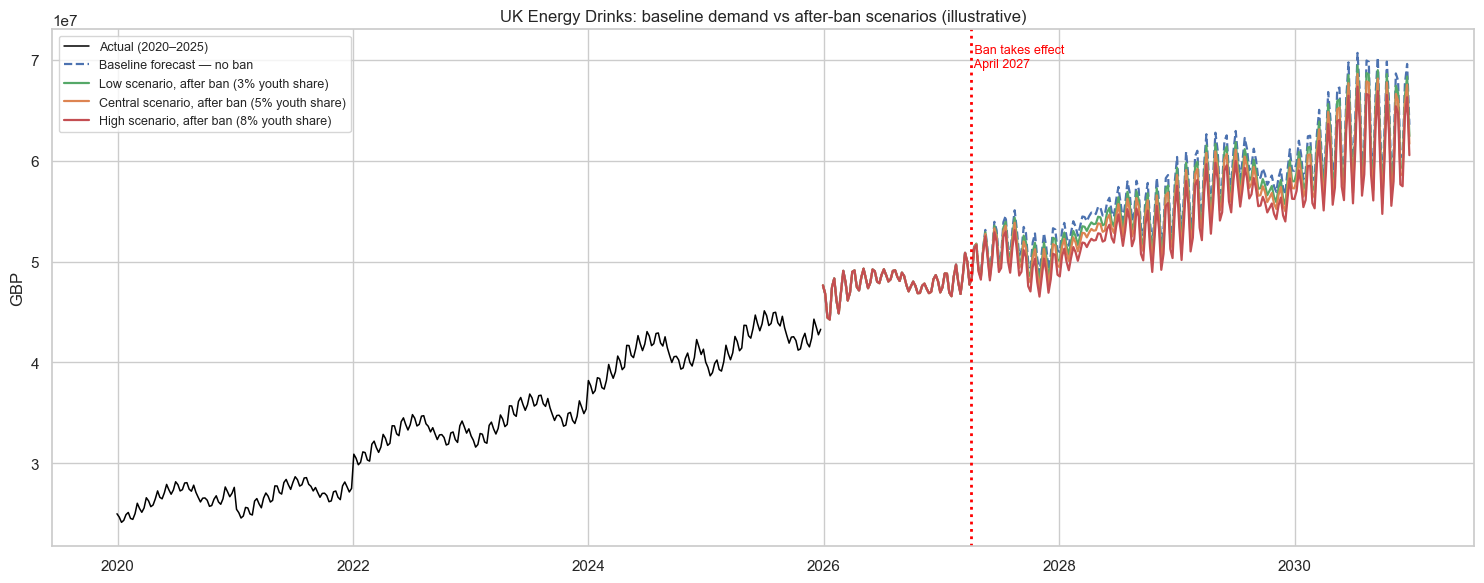

In [38]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Week Start'], df['Estimated Weekly Sales GBP'], color='black', linewidth=1.1, label='Actual (2020–2025)')
ax.plot(future['Week Start'], scenario_forecasts['Baseline (no ban)'],
        color='#4C72B0', linestyle='--', linewidth=1.6, label='Baseline forecast — no ban')

scenario_colors = {'Low': '#55A868', 'Central': '#DD8452', 'High': '#C44E52'}
for label, share in youth_share_scenarios.items():
    key = f'{label} ({share:.0%} youth share)'
    ax.plot(future['Week Start'], scenario_forecasts[key], color=scenario_colors[label],
            linewidth=1.6, label=f'{label} scenario, after ban ({share:.0%} youth share)')

ax.axvline(BAN_DATE, color='red', linestyle=':', linewidth=2)
ax.text(BAN_DATE, ax.get_ylim()[1] * 0.98, ' Ban takes effect\n April 2027', color='red', va='top', fontsize=9)
ax.set_title('UK Energy Drinks: baseline demand vs after-ban scenarios (illustrative)')
ax.set_ylabel('GBP')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

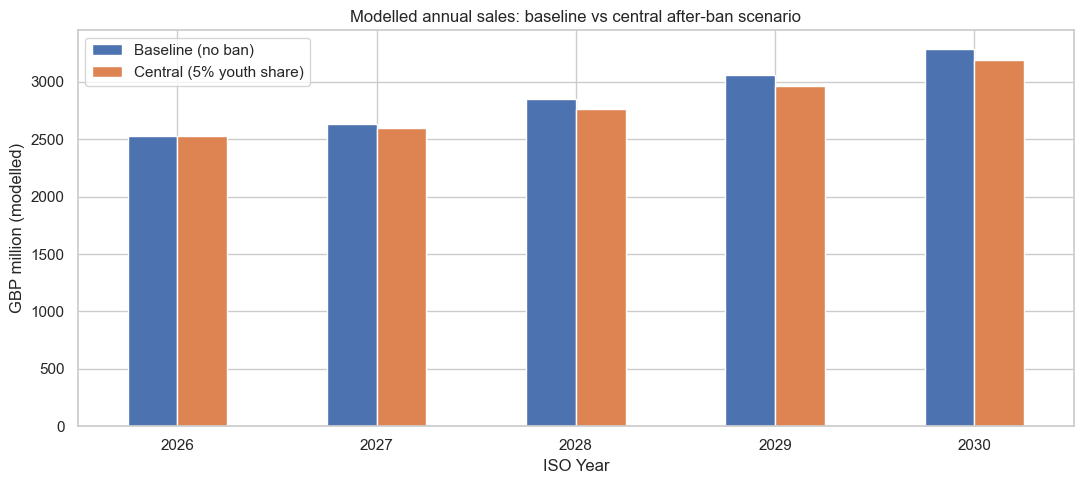

,Baseline (no ban),Low (3% youth share),Central (5% youth share),High (8% youth share)
ISO Year,,,,
2026,2530.2,2530.2,2530.2,2530.2
2027,2637.2,2613.3,2597.3,2573.3
2028,2850.5,2799.8,2766.0,2715.3
2029,3059.3,3004.9,2968.6,2914.2
2030,3285.8,3227.3,3188.4,3129.9


In [39]:
future_annual = future.copy()
future_annual['ISO Year'] = future_annual['Week Start'].dt.isocalendar().year
for key, values in scenario_forecasts.items():
    future_annual[key] = values

annual_compare = future_annual.groupby('ISO Year')[list(scenario_forecasts.keys())].sum() / 1e6
annual_compare = annual_compare[annual_compare.index <= 2030]

ax = annual_compare[['Baseline (no ban)', 'Central (5% youth share)']].plot(
    kind='bar', figsize=(11, 5), color=['#4C72B0', '#DD8452'],
    title='Modelled annual sales: baseline vs central after-ban scenario')
ax.set_ylabel('GBP million (modelled)')
ax.set_xlabel('ISO Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
annual_compare.round(1)

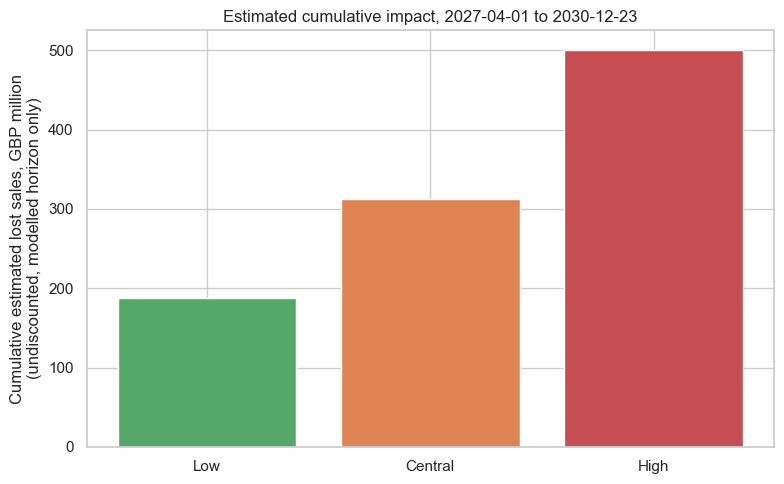

Low: GBP 187,535,756 cumulative modelled impact over the forecast horizon
Central: GBP 312,559,593 cumulative modelled impact over the forecast horizon
High: GBP 500,095,348 cumulative modelled impact over the forecast horizon


In [40]:
cumulative_impact_gbp = {}
for label, share in youth_share_scenarios.items():
    key = f'{label} ({share:.0%} youth share)'
    diff = scenario_forecasts['Baseline (no ban)'] - scenario_forecasts[key]
    cumulative_impact_gbp[label] = diff.sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cumulative_impact_gbp.keys(), [v / 1e6 for v in cumulative_impact_gbp.values()],
       color=[scenario_colors[l] for l in cumulative_impact_gbp])
ax.set_ylabel('Cumulative estimated lost sales, GBP million\n(undiscounted, modelled horizon only)')
ax.set_title(f'Estimated cumulative impact, {BAN_DATE.date()} to {future["Week Start"].max().date()}')
plt.tight_layout()
plt.show()

for label, v in cumulative_impact_gbp.items():
    print(f'{label}: GBP {v:,.0f} cumulative modelled impact over the forecast horizon')

In [41]:
scenario_export = future_annual[['Week Start', 'ISO Year'] + list(scenario_forecasts.keys())].copy()
scenario_export.to_csv(f'{OUTPUTS_DIR}/ban_scenario_forecast.csv', index=False)

scenario_summary = pd.DataFrame({
    'Youth share assumption': [f'{s:.0%}' for s in youth_share_scenarios.values()],
    'Total-market reduction (fully phased in)': [f'{p:.2%}' for p in scenario_impact_pct.values()],
    'Cumulative modelled impact (GBP)': [f'{cumulative_impact_gbp[l]:,.0f}' for l in youth_share_scenarios],
}, index=list(youth_share_scenarios.keys()))
scenario_summary.to_csv(f'{OUTPUTS_DIR}/ban_scenario_summary.csv')
print(f'Saved forecast detail to {OUTPUTS_DIR}/ban_scenario_forecast.csv')
print(f'Saved scenario summary to {OUTPUTS_DIR}/ban_scenario_summary.csv')
scenario_summary

Saved forecast detail to ../outputs_extended/ban_scenario_forecast.csv
Saved scenario summary to ../outputs_extended/ban_scenario_summary.csv


,Youth share assumption,Total-market reduction (fully phased in),Cumulative modelled impact (GBP)
Low,3%,1.78%,"187,535,756"
Central,5%,2.96%,"312,559,593"
High,8%,4.74%,"500,095,348"


## B3. Business recommendation

**On the forecasting approach itself:**
- **Use different models for different decision horizons.** For short-horizon operational decisions (4–8 week ahead replenishment, promotional planning), section 11's walk-forward-retrained Gradient Boosting/XGBoost/Random Forest are the better tool — they read recent momentum and seasonal shape well, and "walk-forward" is exactly how they'd run in production (retrained on a schedule as new EPOS data lands). For long-horizon strategic planning (multi-year revenue projections, capacity/investment decisions), Linear Regression's ability to extrapolate a trend is the more defensible choice, precisely because tree ensembles cannot extrapolate at all, as sections 7–11 demonstrate directly.
- **Never let any of these models "discover" a regulatory shock on its own.** None of the five models has any mechanism for anticipating the April 2027 ban from historical sales patterns — it must be layered on as an explicit, documented scenario, as done in section B2. Any production forecasting pipeline serving this business needs a maintained calendar of known future interventions (this ban, future duty/tax changes, major distribution changes) with the same treatment.
- **Plan with scenario ranges, not single-point forecasts, for 2027 onward.** The Low/Central/High bands above exist because the one input that matters most — the under-16 share of revenue — isn't in this dataset. A single-number forecast would hide that uncertainty rather than communicate it.

**On what the business should actually do, given the policy context:**
- **Commission or acquire age/region/brand-segmented sales data before April 2027.** The `Codebook` sheet already flags exactly this gap (age, sex, region, ethnicity, sugar-status, brand all marked `NOT POPULATED`). Closing it converts the Low/Central/High guesswork into a measured number and is the single highest-value data investment relative to this analysis.
- **Prepare for demand substitution, not just demand loss.** The government's own modelling assumes ~90% of displaced spending moves to other soft drinks rather than leaving the beverage category. A manufacturer concentrated in high-caffeine energy drinks is exposed to the full displacement; a broader beverage portfolio (lower-caffeine variants, soft drinks, ready-to-drink coffee) captures the substitution instead of losing it to competitors.
- **Expect and plan around secondary-channel demand**, not zero under-16 consumption: proxy purchasing via 16+ friends/siblings and parental multi-pack purchases are both flagged as likely continuation routes, which is exactly why this analysis models *displacement*, not elimination.
- **A compliant, lower-caffeine (<150mg/L) product line is a concrete, low-regret hedge** — it directly targets the reformulation trend the market already expects, keeps shelf presence with retailers, and is the most direct way to retain, rather than lose, the youth-adjacent revenue this analysis estimates is at risk.
- **Retailers are far less exposed than manufacturers of high-caffeine SKUs** (per the government's own GBP-estimates: retailers lose GBP 100.5M vs. manufacturers' GBP 658.9M over 25 years) — category mix, not shelf space, is where retailer attention should go.

## B4. Limitations specific to this scenario analysis

- **The youth-share assumption is illustrative, not measured** — this is the single biggest source of uncertainty in the after-ban numbers above, and it's clearly labelled and easy to re-run with different values (`youth_share_scenarios` in section B2's code).
- **The recursive forecast compounds error the further out it runs** — treat the 2029–2030 tail of the baseline as considerably less reliable than 2026–2027, independent of the ban itself.
- **The displacement factor (59.3%) and the 90%-substitution assumption are taken as given from the government's own impact assessment**, not independently verified here.
- **The underlying `Weekly_Sales` data is itself modelled, not observed** (see the `Overview` sheet, and the caveat repeated throughout Part 1) — this scenario analysis is a second layer of modelling on top of already-modelled data. Treat every number in Part 2 as illustrative of a *method*, not as a number to put in a business plan without validating against real sales and real segment data.
- **The ban's scope is England-only**, while `Weekly_Sales` is described as a GB/UK-wide market anchor; no England-only share adjustment is attempted here, consistent with the same data-availability gap noted above.